In [2]:
import json
import statistics as st
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path("..")

# Each condition pairs a fork run with the rewards.json of the trajectory set it
# was forked from (verified by matching fork_summary "old_score" against the
# rewards.json values — mismatched pairs mean the fork run came from a different
# benchmark run than the rewards file).
CONDITIONS = {
    "w/o protocol": {
        "fork_summary": ROOT / "forks/fork_summary.json",
        "rewards": ROOT / "benchmark_results_hypotest/rewards.json",
        "color": "#dd8452",
    },
    "w/ protocol": {
        "fork_summary": ROOT / "forks-w/fork_summary.json",
        "rewards": ROOT / "benchmark_results_hypotest-w/rewards.json",
        "color": "#55a868",
    },
}

runs = {}
for name, cfg in CONDITIONS.items():
    summary = json.load(open(cfg["fork_summary"]))
    runs[name] = {
        "color": cfg["color"],
        "forked": summary["forked"],
        "skipped": summary["skipped"],
        "failed": summary["failed"],
        "rewards": json.load(open(cfg["rewards"])),
    }
    r = runs[name]
    print(f"[{name}] forked={len(r['forked'])} skipped={len(r['skipped'])} failed={len(r['failed'])}")

print("\nsample forked record keys:")
print(list(runs["w/ protocol"]["forked"][0].keys()))

FileNotFoundError: [Errno 2] No such file or directory: '../forks/fork_summary.json'

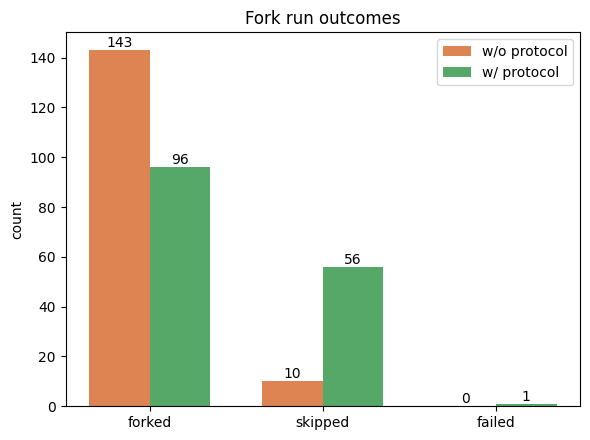

In [26]:
# --- Plot: fork outcome counts, w/o protocol vs w/ protocol ---
cats = ["forked", "skipped", "failed"]
x = np.arange(len(cats)); w = 0.35

fig, ax = plt.subplots(figsize=(6, 4.5))
for i, (name, run) in enumerate(runs.items()):
    counts = [len(run["forked"]), len(run["skipped"]), len(run["failed"])]
    bars = ax.bar(x + (i - 0.5) * w, counts, w, label=name, color=run["color"])
    ax.bar_label(bars)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("count")
ax.set_title("Fork run outcomes")
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
def delta_stats(F):
    deltas = [f["new_score"] - f["old_score"] for f in F]
    imp   = [f for f in F if f["new_score"] > f["old_score"]]
    worse = [f for f in F if f["new_score"] < f["old_score"]]
    same  = [f for f in F if f["new_score"] == f["old_score"]]
    return {"deltas": deltas, "imp": imp, "worse": worse, "same": same}

for name, run in runs.items():
    run.update(delta_stats(run["forked"]))
    d = run["deltas"]
    print(f"[{name}]")
    print(f"  forks: {len(run['forked'])}")
    print(f"  improved: {len(run['imp'])}  worse: {len(run['worse'])}  same: {len(run['same'])}")
    print(f"  mean delta: {st.mean(d):.4f}   median delta: {st.median(d):.4f}")
    old_mean = st.mean([f["old_score"] for f in run["forked"]])
    new_mean = st.mean([f["new_score"] for f in run["forked"]])
    print(f"  mean old -> new: {old_mean:.4f} -> {new_mean:.4f}\n")

[w/o protocol]
  forks: 143
  improved: 93  worse: 22  same: 28
  mean delta: 0.1485   median delta: 0.1000
  mean old -> new: 0.4327 -> 0.5812

[w/ protocol]
  forks: 96
  improved: 46  worse: 29  same: 21
  mean delta: 0.1064   median delta: 0.0000
  mean old -> new: 0.4844 -> 0.5908



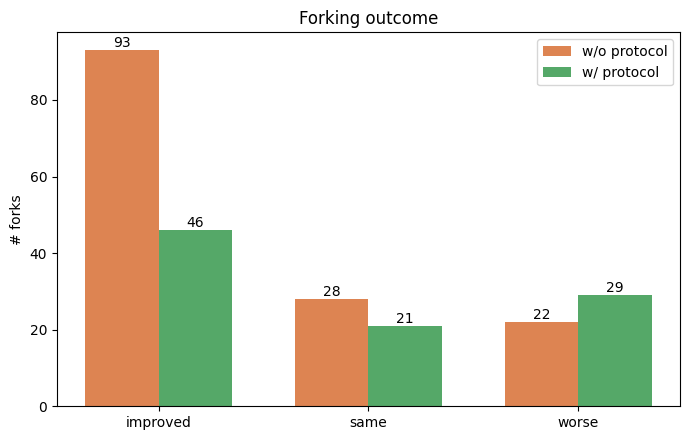

In [28]:
# --- Plot: outcome of forking, w/o protocol vs w/ protocol ---
cats = ["improved", "same", "worse"]
x = np.arange(len(cats)); w = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (name, run) in enumerate(runs.items()):
    counts = [len(run["imp"]), len(run["same"]), len(run["worse"])]
    bars = ax.bar(x + (i - 0.5) * w, counts, w, label=name, color=run["color"])
    ax.bar_label(bars)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("# forks")
ax.set_title("Forking outcome")
ax.legend()
plt.tight_layout()
plt.show()

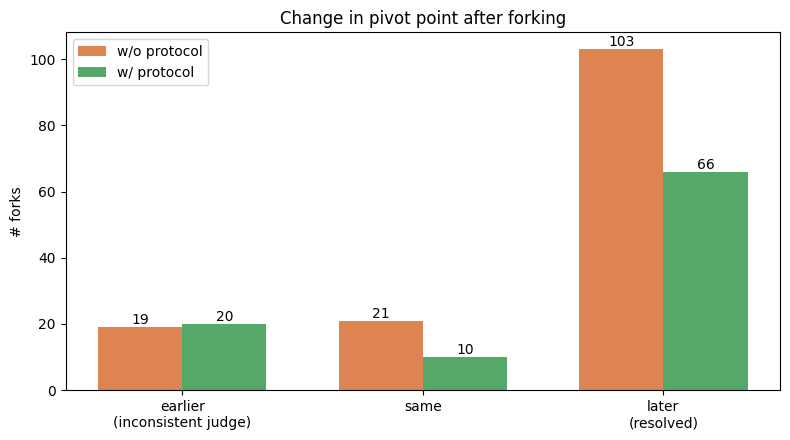

In [39]:
# --- Plot: change in first_wrong_step, w/o protocol vs w/ protocol ---
# None first_wrong_step = no wrong step remains (fully correct) => treated as "past the end".
# Later (or resolved) first wrong step = improvement.
def fws_counts(forked):
    dec = same = inc = 0
    for f in forked:
        o = float("inf") if f["old_first_wrong_step"] is None else f["old_first_wrong_step"]
        n = float("inf") if f["new_first_wrong_step"] is None else f["new_first_wrong_step"]
        if n > o:
            inc += 1
        elif n < o:
            dec += 1
        else:
            same += 1
    return [dec, same, inc]

cats = ["earlier\n(inconsistent judge)", "same", "later\n(resolved)"]
x = np.arange(len(cats)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (name, run) in enumerate(runs.items()):
    counts = fws_counts(run["forked"])
    bars = ax.bar(x + (i - 0.5) * w, counts, w, label=name, color=run["color"])
    ax.bar_label(bars)
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("# forks")
ax.set_title("Change in pivot point after forking")
ax.legend()
plt.tight_layout()
plt.show()

w/o protocol: 21/143 forks at cell 0  meanΔ=+0.151
w/ protocol: 10/96 forks at cell 0  meanΔ=+0.188


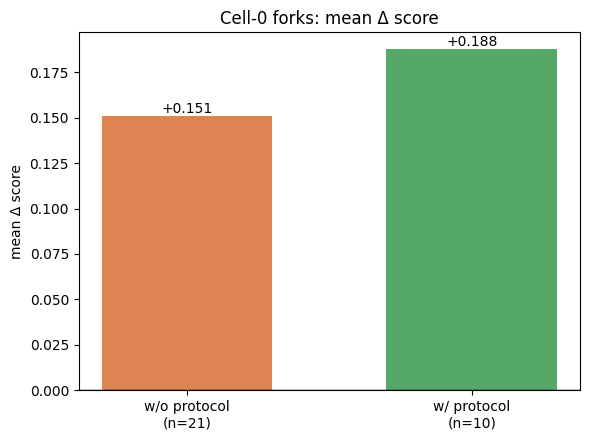

In [30]:
# --- Forks at cell 0: how many, and do they improve rewards? ---
def cell0_stats(forked):
    g = [f for f in forked if f["fork_cell"] == 0]
    dl = [f["new_score"] - f["old_score"] for f in g]
    return {"n_total": len(forked), "n_cell0": len(g), "meanD": st.mean(dl) if dl else 0.0}

cell0_summary = {name: cell0_stats(run["forked"]) for name, run in runs.items()}
for name, s in cell0_summary.items():
    print(f"{name}: {s['n_cell0']}/{s['n_total']} forks at cell 0  meanΔ={s['meanD']:+.3f}")

labels = list(cell0_summary)
vals = [cell0_summary[l]["meanD"] for l in labels]
colors = [runs[l]["color"] for l in labels]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, vals, color=colors, width=0.6)
ax.bar_label(bars, fmt="%+.3f")
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels([f"{l}\n(n={cell0_summary[l]['n_cell0']})" for l in labels])
ax.set_ylabel("mean Δ score")
ax.set_title("Cell-0 forks: mean Δ score")
plt.tight_layout()
plt.show()

In [31]:
def task_level_metrics(F, rewards):
    fork_new = {}
    for f in F:
        sid = f["source_traj_id"]
        fork_new[sid] = max(fork_new.get(sid, -1), f["new_score"])

    tasks = defaultdict(dict)
    for k, v in rewards.items():
        t, rep = k.rsplit("_rep", 1)
        tasks[t][int(rep)] = v

    repl = defaultdict(dict)
    for t, reps in tasks.items():
        for rep, v in reps.items():
            sid = f"{t}_rep{rep}"
            repl[t][rep] = fork_new.get(sid, v)

    def metrics(scoremap):
        avg  = [st.mean(list(r.values())) for r in scoremap.values()]
        best = [max(r.values())           for r in scoremap.values()]
        return st.mean(avg), st.mean(best)

    def passrate(scoremap, thr):
        return st.mean([1.0 if max(r.values()) >= thr else 0.0 for r in scoremap.values()])

    o_avg, o_best = metrics(tasks)
    r_avg, r_best = metrics(repl)
    return {
        "tasks": tasks, "repl": repl,
        "o_avg": o_avg, "o_best": o_best, "r_avg": r_avg, "r_best": r_best,
        "passrate": passrate,
    }

for name, run in runs.items():
    run.update(task_level_metrics(run["forked"], run["rewards"]))
    print(f"[{name}]  n_tasks = {len(run['tasks'])}")
    print(f"{'':14s}{'avg@3':>10s}{'best@3':>10s}")
    print(f"{'ORIGINAL':14s}{run['o_avg']:10.4f}{run['o_best']:10.4f}")
    print(f"{'FORKED':14s}{run['r_avg']:10.4f}{run['r_best']:10.4f}")
    for thr in (1.0, 0.9, 0.8):
        o = run["passrate"](run["tasks"], thr)
        r = run["passrate"](run["repl"], thr)
        print(f"  pass@3 (max>={thr}):  ORIG={o:.3f}   FORKED={r:.3f}")
    print()

[w/o protocol]  n_tasks = 51
                   avg@3    best@3
ORIGINAL          0.4633    0.5644
FORKED            0.6021    0.7361
  pass@3 (max>=1.0):  ORIG=0.118   FORKED=0.392
  pass@3 (max>=0.9):  ORIG=0.216   FORKED=0.471
  pass@3 (max>=0.8):  ORIG=0.333   FORKED=0.627

[w/ protocol]  n_tasks = 51
                   avg@3    best@3
ORIGINAL          0.6699    0.7706
FORKED            0.7367    0.8422
  pass@3 (max>=1.0):  ORIG=0.549   FORKED=0.627
  pass@3 (max>=0.9):  ORIG=0.608   FORKED=0.686
  pass@3 (max>=0.8):  ORIG=0.647   FORKED=0.725



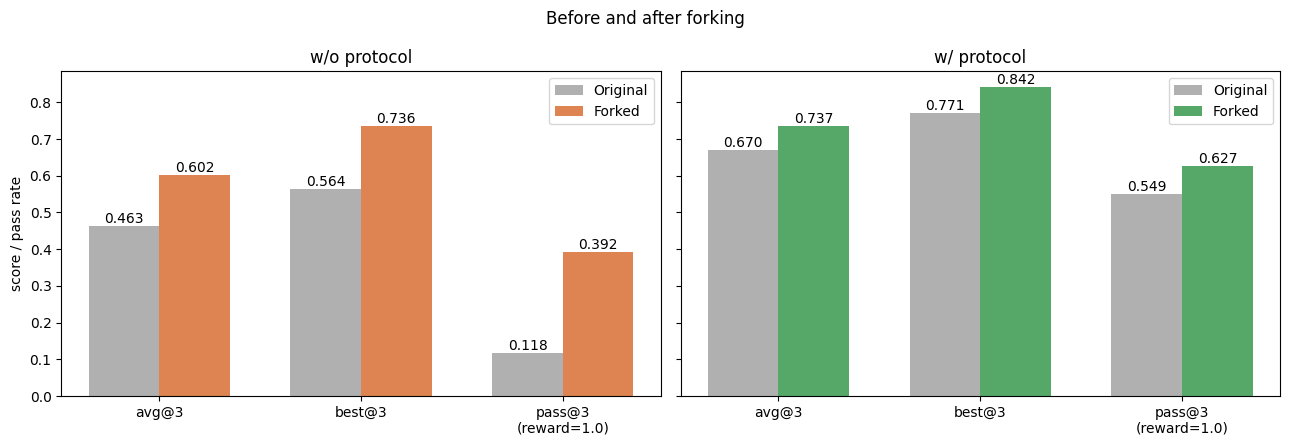

In [32]:
# --- Plot: task-level ORIGINAL vs FORKED, w/o protocol vs w/ protocol ---
names = ["avg@3", "best@3", "pass@3\n(reward=1.0)"]
x = np.arange(len(names)); w = 0.35

fig, axes = plt.subplots(1, len(runs), figsize=(6.5 * len(runs), 4.5), sharey=True)
for ax, (name, run) in zip(axes, runs.items()):
    orig = [run["o_avg"], run["o_best"], run["passrate"](run["tasks"], 1.0)]
    fork = [run["r_avg"], run["r_best"], run["passrate"](run["repl"], 1.0)]
    b1 = ax.bar(x - w/2, orig, w, label="Original", color="#b0b0b0")
    b2 = ax.bar(x + w/2, fork, w, label="Forked", color=run["color"])
    ax.bar_label(b1, fmt="%.3f"); ax.bar_label(b2, fmt="%.3f")
    ax.set_xticks(x); ax.set_xticklabels(names)
    ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("score / pass rate")
fig.suptitle("Before and after forking")
plt.tight_layout()
plt.show()

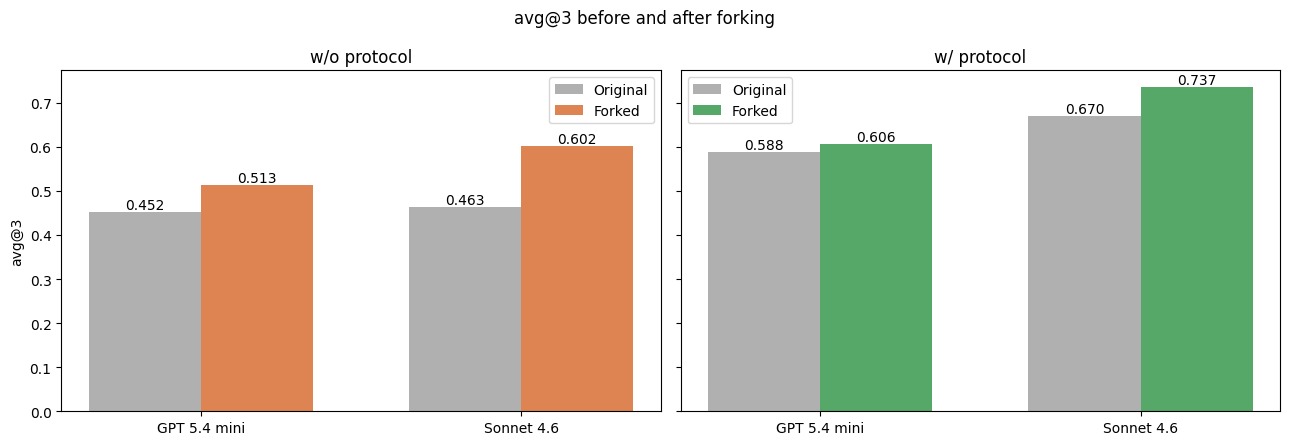

In [34]:
# --- Plot: avg@3 before and after forking, Sonnet 4.6 vs GPT 5.4 mini ---
GPT_54_MINI = {
    "w/o protocol": {"orig": 0.452, "fork": 0.513},
    "w/ protocol":  {"orig": 0.588, "fork": 0.606},
}

models = ["GPT 5.4 mini", "Sonnet 4.6"]
x = np.arange(len(models)); w = 0.35

fig, axes = plt.subplots(1, len(runs), figsize=(6.5 * len(runs), 4.5), sharey=True)
for ax, (name, run) in zip(axes, runs.items()):
    orig = [GPT_54_MINI[name]["orig"], run["o_avg"]]
    fork = [GPT_54_MINI[name]["fork"], run["r_avg"]]
    b1 = ax.bar(x - w/2, orig, w, label="Original", color="#b0b0b0")
    b2 = ax.bar(x + w/2, fork, w, label="Forked", color=run["color"])
    ax.bar_label(b1, fmt="%.3f"); ax.bar_label(b2, fmt="%.3f")
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("avg@3")
fig.suptitle("avg@3 before and after forking")
plt.tight_layout()
plt.show()

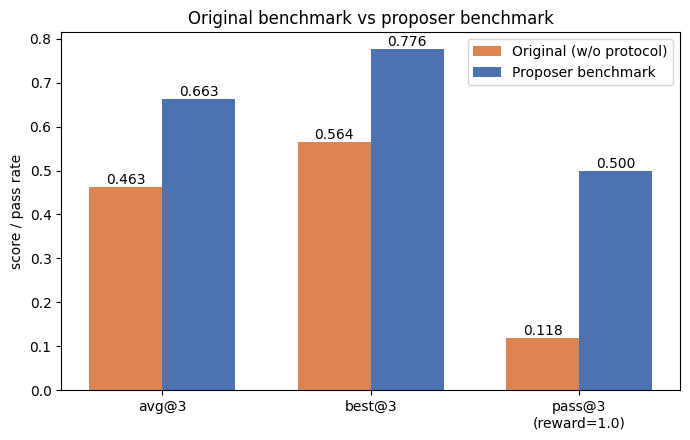

In [ ]:
# --- Plot: avg@3 / best@3 / pass@3, original (w/o protocol) vs proposer benchmark ---
proposer_rewards = json.load(open(ROOT / "benchmark_results_proposer/rewards.json"))

def rewards_to_taskmap(rewards):
    tasks = defaultdict(dict)
    for k, v in rewards.items():
        t, rep = k.rsplit("_rep", 1)
        tasks[t][int(rep)] = v
    return tasks

def bench_metrics(scoremap):
    avg = st.mean([st.mean(list(r.values())) for r in scoremap.values()])
    best = st.mean([max(r.values()) for r in scoremap.values()])
    passr = st.mean([1.0 if max(r.values()) >= 1.0 else 0.0 for r in scoremap.values()])
    return avg, best, passr

orig_vals = bench_metrics(runs["w/o protocol"]["tasks"])
proposer_vals = bench_metrics(rewards_to_taskmap(proposer_rewards))

names = ["avg@3", "best@3", "pass@3\n(reward=1.0)"]
x = np.arange(len(names)); w = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
b1 = ax.bar(x - w/2, orig_vals, w, label="Original (w/o protocol)", color="#dd8452")
b2 = ax.bar(x + w/2, proposer_vals, w, label="Proposer benchmark", color="#4c72b0")
ax.bar_label(b1, fmt="%.3f"); ax.bar_label(b2, fmt="%.3f")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("score / pass rate")
ax.set_title("Original benchmark vs proposer benchmark")
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
def band_table(F, key, bands):
    for lo, hi in bands:
        g = [f for f in F if lo <= key(f) < hi]
        if not g:
            continue
        dl = [f["new_score"] - f["old_score"] for f in g]
        i = sum(x > 0 for x in dl); w = sum(x < 0 for x in dl)
        print(f"  [{lo:.2f},{hi:.2f}): n={len(g):2d}  meanΔ={st.mean(dl):+.3f}  imp={i:2d} worse={w:2d}")
    print()

score_bands = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]
step_bands  = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.01), (0, 0.01)]

for name, run in runs.items():
    print(f"=== {name} — original score ===")
    band_table(run["forked"], lambda f: f["old_score"], score_bands)
    print(f"=== {name} — fork position (fork_cell / total steps) ===")
    band_table(run["forked"], lambda f: f["fork_cell"] / max(f["n_steps_total"], 1), step_bands)

=== w/o protocol — original score ===
  [0.00,0.20): n=30  meanΔ=+0.224  imp=17 worse= 1
  [0.20,0.40): n=36  meanΔ=+0.215  imp=25 worse= 6
  [0.40,0.60): n=36  meanΔ=+0.139  imp=21 worse= 7
  [0.60,0.80): n=11  meanΔ=+0.033  imp= 6 worse= 4
  [0.80,1.01): n=30  meanΔ=+0.047  imp=24 worse= 4

=== w/o protocol — fork position (fork_cell / total steps) ===
  [0.00,0.20): n=50  meanΔ=+0.177  imp=35 worse= 2
  [0.20,0.40): n=50  meanΔ=+0.183  imp=36 worse= 7
  [0.40,0.60): n=32  meanΔ=+0.088  imp=16 worse=10
  [0.60,1.01): n=11  meanΔ=+0.037  imp= 6 worse= 3
  [0.00,0.01): n=21  meanΔ=+0.151  imp=13 worse= 1

=== w/ protocol — original score ===
  [0.00,0.20): n=15  meanΔ=+0.339  imp=11 worse= 0
  [0.20,0.40): n=20  meanΔ=+0.156  imp=10 worse= 7
  [0.40,0.60): n=35  meanΔ=+0.120  imp=16 worse=13
  [0.60,0.80): n= 4  meanΔ=-0.078  imp= 2 worse= 1
  [0.80,1.01): n=22  meanΔ=-0.085  imp= 7 worse= 8

=== w/ protocol — fork position (fork_cell / total steps) ===
  [0.00,0.20): n=28  meanΔ=+0.12

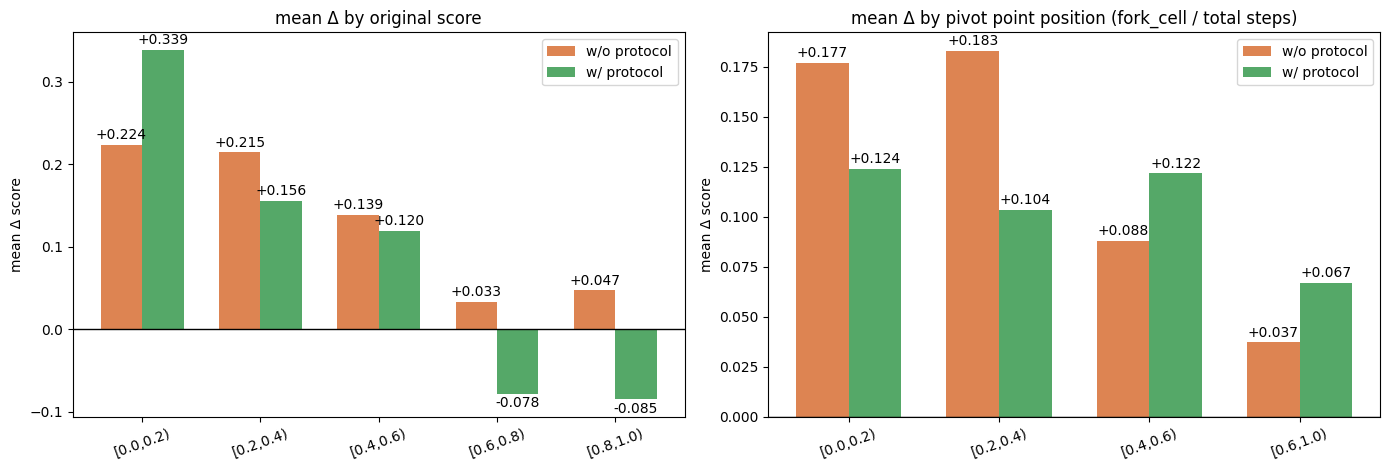

In [35]:
# --- Plot: mean delta by band, w/o protocol vs w/ protocol ---
def band_means(F, key, bands):
    labels, mean_d = [], []
    for lo, hi in bands:
        g = [f for f in F if lo <= key(f) < hi]
        labels.append(f"[{lo:.1f},{hi:.1f})")
        mean_d.append(st.mean([f["new_score"] - f["old_score"] for f in g]) if g else float("nan"))
    return labels, mean_d

score_bands = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]
step_bands  = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.01)]

specs = [
    ("original score", lambda f: f["old_score"], score_bands),
    ("pivot point position (fork_cell / total steps)",
     lambda f: f["fork_cell"] / max(f["n_steps_total"], 1), step_bands),
]

w = 0.35
fig, axes = plt.subplots(1, len(specs), figsize=(7 * len(specs), 4.8))
for ax, (title, key, bands) in zip(axes, specs):
    labels = None
    for i, (name, run) in enumerate(runs.items()):
        labels, vals = band_means(run["forked"], key, bands)
        x = np.arange(len(labels))
        bars = ax.bar(x + (i - 0.5) * w, vals, w, label=name, color=run["color"])
        ax.bar_label(bars, fmt="%+.3f", padding=2)
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, rotation=20)
    ax.set_ylabel("mean Δ score")
    ax.set_title(f"mean Δ by {title}")
    ax.legend()

plt.tight_layout()
plt.show()

## Sequential Forking

n_tasks=51  n_traj=153  chains=141 skipped=10 failed=2  max rounds=5

  round     avg@3    best@3    pass@3
      0    0.4633    0.5644    0.1176 (original)
      1    0.6522    0.7848    0.4902
      2    0.7443    0.8513    0.6863
      3    0.7713    0.8929    0.7451
      4    0.7848    0.8905    0.7843
      5    0.8060    0.8916    0.7843


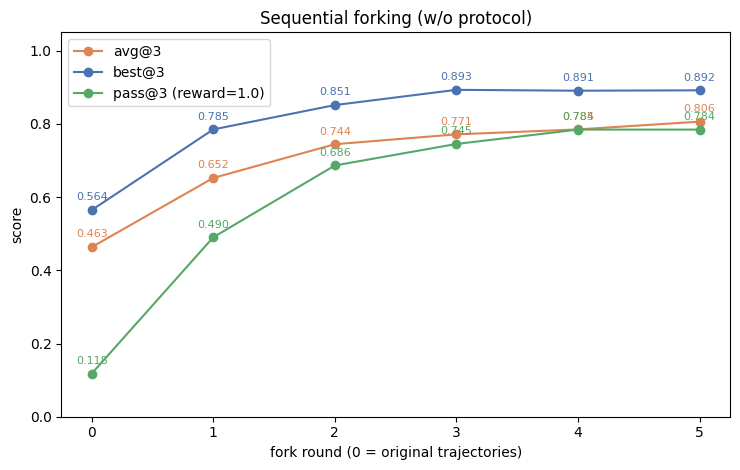

In [5]:
# --- Sequential forking (w/o protocol): avg@3 / best@3 / pass@3 per fork round ---
# Each chain in fork_summary carries score_trace = [original, after r1, after r2, ...].
# A chain that stops early (full_reward / no_wrong_step) keeps its last score for the
# remaining rounds; trajectories that were skipped or failed keep their original reward.
SEQ = ROOT / "archive/sonnet-judge/seq-forks-hypotest-wo-protocol/fork_summary.json"
SEQ_REWARDS = ROOT / "archive/sonnet-judge/benchmark_results-hypotest-wo-protocol/rewards.json"

seq = json.load(open(SEQ))
seq_rewards = json.load(open(SEQ_REWARDS))

# score_trace per trajectory; no chain (skipped/failed) => flat at the original reward
seq_traces = {k: [v] for k, v in seq_rewards.items()}
for c in seq["chains"]:
    assert abs(c["score_trace"][0] - seq_rewards[c["source_traj_id"]]) < 1e-9, c["source_traj_id"]
    seq_traces[c["source_traj_id"]] = c["score_trace"]

N_ROUNDS = max(len(t) for t in seq_traces.values()) - 1

seq_tasks = defaultdict(list)
for k in seq_traces:
    seq_tasks[k.rsplit("_rep", 1)[0]].append(k)

def score_at(traj, r):
    """Score of `traj` after r fork rounds (held flat once its chain stopped)."""
    tr = seq_traces[traj]
    return tr[min(r, len(tr) - 1)]

def round_metrics(r, thr=1.0):
    per_task = [[score_at(k, r) for k in reps] for reps in seq_tasks.values()]
    return (
        st.mean([st.mean(v) for v in per_task]),                       # avg@3
        st.mean([max(v) for v in per_task]),                           # best@3
        st.mean([1.0 if max(v) >= thr else 0.0 for v in per_task]),    # pass@3
    )

seq_rows = [round_metrics(r) for r in range(N_ROUNDS + 1)]

n_skipped = len(seq["skipped"]); n_failed = len(seq["failed"])
print(f"n_tasks={len(seq_tasks)}  n_traj={len(seq_traces)}  chains={len(seq['chains'])} "
      f"skipped={n_skipped} failed={n_failed}  max rounds={N_ROUNDS}")
print(f"\n{'round':>7}{'avg@3':>10}{'best@3':>10}{'pass@3':>10}")
for r, (a, b, p) in enumerate(seq_rows):
    tag = " (original)" if r == 0 else ""
    print(f"{r:>7}{a:10.4f}{b:10.4f}{p:10.4f}{tag}")

# --- Plot: metric vs fork round ---
rounds = np.arange(N_ROUNDS + 1)
series = [("avg@3", "#dd8452"), ("best@3", "#4c72b0"), ("pass@3 (reward=1.0)", "#55a868")]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
for i, (label, color) in enumerate(series):
    vals = [row[i] for row in seq_rows]
    ax.plot(rounds, vals, marker="o", color=color, label=label)
    for x_, y_ in zip(rounds, vals):
        ax.annotate(f"{y_:.3f}", (x_, y_), textcoords="offset points", xytext=(0, 7),
                    ha="center", fontsize=8, color=color)
ax.set_xticks(rounds)
ax.set_xlabel("fork round (0 = original trajectories)")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.set_title("Sequential forking (w/o protocol)")
ax.legend()
plt.tight_layout()
plt.show()